# IMEN266 · Ch.4 · Class Problems 5 — Limiting behavior, cost and reward

**How this notebook works** — every problem follows the same 5 steps:

> **Problem → Model → Analytic → Simulate & Visualize → Experiment**

The analytic answer and the simulation must agree. *That agreement — not the
instructor, not an AI — is your ground truth.*

**In-class version only:** cells marked `# TODO` are for you to complete during
class. A `check(...)` cell right after tells you immediately whether your answer
matches the reference value.

▶ Open in Colab: `https://colab.research.google.com/github/youngmko/imen266-2026/blob/main/ch04/notebooks/CP5_limiting_cost.ipynb`

**The theorem of this notebook** *(slides pp. 29–37, 45/52; Companion Proofs 3–6)*

- If the chain is **irreducible and positive recurrent** (every finite irreducible
  chain is), the equations
  $$\pi=\pi P,\qquad \sum_{i\in\mathcal S}\pi_i=1$$
  have a **unique** solution $\pi$ — the *stationary distribution*; $\pi_i$ is the
  long-run fraction of time in $i$, and $1/\pi_i$ is the mean return time to $i$.
- If the chain is also **aperiodic** (⇒ *ergodic*), then $\lim_{n\to\infty}P(X_n=i)=\pi_i$
  whatever the initial distribution.
- **Cost/reward:** if cost $C(i)$ is incurred whenever the chain is in $i$, the
  long-run average cost per observation is $\sum_i C(i)\,\pi_i$.

In code: `chain.summary()` classifies states; `chain.stationary()` solves for $\pi$;
`chain.mean_return_times()` gives $1/\pi$; `chain.long_run_cost(c)` gives $\sum_i c_i\pi_i$.

In [1]:
# --- IMEN266 setup (Ch.4): course package + helpers ---------------------------
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

try:                                   # local clone / PLMS zip: package is on the path
    from imen266.dtmc import DTMC
except ImportError:                    # Colab: fetch the course package from GitHub (~5 s)
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/youngmko/imen266-2026.git"], check=True)
    from imen266.dtmc import DTMC
from imen266.check import check        # [TODO]/[OK]/[X] self-check (unfinished TODOs never crash)

rng = np.random.default_rng(2026)
plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11,
                     "legend.frameon": False})

def build_chain(P, states=None):
    """DTMC(P) if P is complete and valid; otherwise None (keeps 'Run all' alive)."""
    P = np.asarray(P, dtype=float)
    if np.isnan(P).any():
        print("[TODO] P still contains NaN entries - finish the TODO above."); return None
    try:
        return DTMC(P, states)
    except ValueError as e:
        print("[X  ] P is not a valid transition matrix:", e); return None

def check_rows(P):
    """Every row of a transition matrix must sum to 1 (and be nonnegative)."""
    P = np.asarray(P, dtype=float)
    err = None if np.isnan(P).any() else float(np.abs(P.sum(axis=1) - 1).max() + (P < 0).sum())
    return check("rows sum to 1, entries >= 0", err, 0.0, tol=1e-9)

try:
    from ipywidgets import interact, FloatSlider, IntSlider, FloatLogSlider
    HAS_W = True
except Exception:
    HAS_W = False

def show(fn, **sliders):
    """interact() if widgets are available; otherwise draw once with defaults."""
    if HAS_W:
        interact(fn, **sliders)
    else:
        fn(**{k: getattr(v, "value", v) for k, v in sliders.items()})

print("Setup OK.  DTMC imported.  Widgets available:", HAS_W)

Setup OK.  DTMC imported.  Widgets available: True


---
## Warm-up · Classifying states *(slides pp. 29–33/52)*

The two matrices on slide 29/52, plus a 3-cycle. For each: communicating classes,
recurrent vs transient, period — and what happens to $P^n$ as $n$ grows.
The point: **a limit of $p_n$ needs all three of irreducible / positive recurrent /
aperiodic; a stationary $\pi$ needs only the first two.**

In [3]:
P_A = [[0.6, 0.4, 0, 0, 0], [0.8, 0.2, 0, 0, 0], [0, 0, 0.3, 0.2, 0.5], [0, 0, 0, 1, 0], [0, 0, 0.8, 0.1, 0.1]]
P_B = [[0.6, 0.4, 0, 0, 0], [0.3, 0.7, 0, 0, 0], [0.2, 0.2, 0.2, 0.2, 0.2], [0, 0, 0, 0.5, 0.5], [0, 0, 0, 0.5, 0.5]]
P_C = [[0, 1, 0], [0, 0, 1], [1, 0, 0]]                       # the 3-cycle: periodic

for name, P in [("A (slide, top)", P_A), ("B (slide, bottom)", P_B), ("C (3-cycle)", P_C)]:
    ch = DTMC(P, states=list(range(1, len(P) + 1)))
    print(f"--- chain {name} ---"); print(ch.summary())
    print("P^50 (rows):\n", ch.n_step(50).round(3), "\n")

--- chain A (slide, top) ---
5 states; 3 communicating class(es)
  [1, 2]: recurrent, period 1
  [3, 5]: transient, period 1
  [4]: recurrent, period 1
absorbing: [4]
ergodic: False
P^50 (rows):
 [[0.667 0.333 0.    0.    0.   ]
 [0.667 0.333 0.    0.    0.   ]
 [0.    0.    0.    1.    0.   ]
 [0.    0.    0.    1.    0.   ]
 [0.    0.    0.    1.    0.   ]] 

--- chain B (slide, bottom) ---
5 states; 3 communicating class(es)
  [1, 2]: recurrent, period 1
  [3]: transient, period 1
  [4, 5]: recurrent, period 1
absorbing: none
ergodic: False
P^50 (rows):
 [[0.429 0.571 0.    0.    0.   ]
 [0.429 0.571 0.    0.    0.   ]
 [0.214 0.286 0.    0.25  0.25 ]
 [0.    0.    0.    0.5   0.5  ]
 [0.    0.    0.    0.5   0.5  ]] 

--- chain C (3-cycle) ---
3 states; 1 communicating class(es)
  [1, 2, 3]: recurrent, period 3
absorbing: none
ergodic: False
P^50 (rows):
 [[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]] 



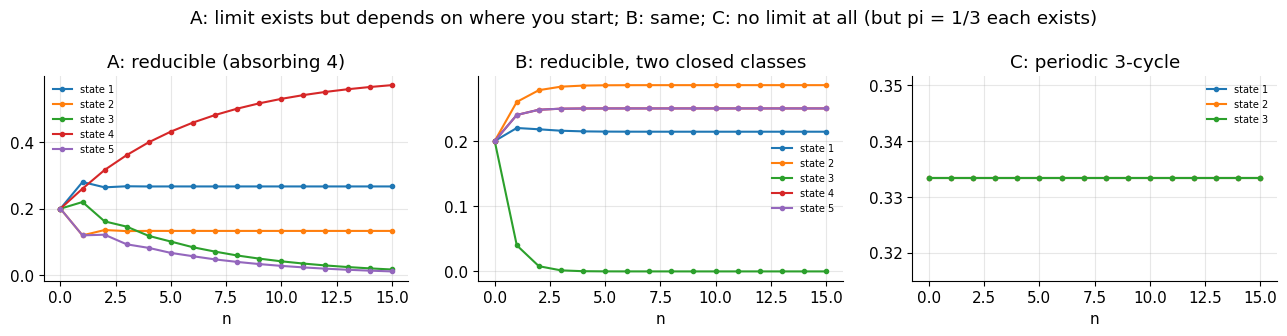

In [4]:
# --- Visualize: p_n for the three chains from a uniform start ---------------------
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
for a, (name, P) in zip(ax, [("A: reducible (absorbing 4)", P_A), ("B: reducible, two closed classes", P_B), ("C: periodic 3-cycle", P_C)]):
    ch = DTMC(P); path = ch.distribution_path(np.full(ch.n, 1/ch.n), 15)
    for j in range(ch.n): a.plot(path[:, j], "o-", ms=3, label=f"state {j+1}")
    a.set_title(name); a.set_xlabel("n"); a.legend(fontsize=7)
plt.suptitle("A: limit exists but depends on where you start; B: same; C: no limit at all (but pi = 1/3 each exists)")
plt.tight_layout(); plt.show()

---
## Problem 1 — Machine up / down in the long run *(slide p. 38/52)*

> Consider problem #1 in Class Problems 3 on DTMC modeling. [...] For this system,
> **compute the steady state probabilities that the machine is up and down at
> the beginning of a day in the long run.**

### Model
$P=\begin{pmatrix}0.03&0.97\\0.02&0.98\end{pmatrix}$ (down, up); irreducible and
aperiodic ⇒ ergodic. Balance: $\pi_0=0.03\pi_0+0.02\pi_1$, i.e.
$0.97\,\pi_0=0.02\,\pi_1$ ("flow down→up = flow up→down"), with $\pi_0+\pi_1=1$:
$$\pi_{\text{down}}=\frac{0.02}{0.97+0.02},\qquad \pi_{\text{up}}=\frac{0.97}{0.99}.$$

In [5]:
machine = DTMC([[0.03, 0.97], [0.02, 0.98]], ["down", "up"])
print(machine.summary())

pi_down = 0.02 / (0.97 + 0.02)          # balance across the cut {down} | {up}
pi_up   = 0.97 / (0.97 + 0.02)
print(f"by hand: pi = ({pi_down:.4f}, {pi_up:.4f})")
print( "solver : pi =", machine.stationary().round(4))
print( "mean return times 1/pi:", machine.mean_return_times().round(2), "days")

2 states; 1 communicating class(es)
  ['down', 'up']: recurrent, period 1
absorbing: none
ergodic: True
by hand: pi = (0.0202, 0.9798)
solver : pi = [0.0202 0.9798]
mean return times 1/pi: [49.5   1.02] days


In [6]:
check("pi_down", pi_down, 0.02/0.99, tol=1e-9)
check("pi_up",   pi_up,   0.97/0.99, tol=1e-9)

[OK ] pi_down: got 0.020202   (reference 0.020202)
[OK ] pi_up: got 0.979798   (reference 0.979798)


True

long-run fraction of days up (sim): 0.983


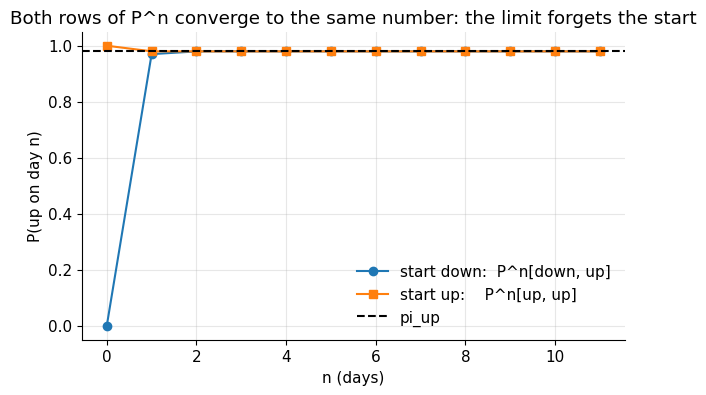

In [7]:
# --- Simulate one machine for 20 years; watch the rows of P^n collapse onto pi -----
x = machine.sample_path(20 * 365, x0="down", rng=rng)
print("long-run fraction of days up (sim):", machine.occupancy(x)[1].round(4))

ns = np.arange(0, 12)
rows = np.array([machine.n_step(n)[:, 1] for n in ns])       # P^n[., up]
plt.figure()
plt.plot(ns, rows[:, 0], "o-", label="start down:  P^n[down, up]")
plt.plot(ns, rows[:, 1], "s-", label="start up:    P^n[up, up]")
plt.axhline(0.97/0.99, ls="--", c="k", label="pi_up"); plt.xlabel("n (days)"); plt.ylabel("P(up on day n)")
plt.title("Both rows of P^n converge to the same number: the limit forgets the start"); plt.legend(); plt.show()

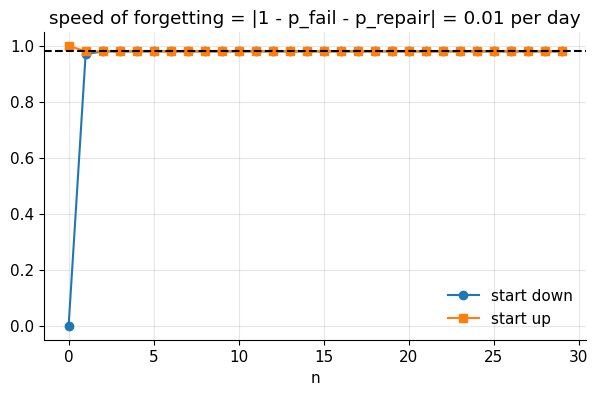

In [8]:
def two_state_exp(p_fail=0.02, p_repair=0.97):
    ch = DTMC([[1-p_repair, p_repair], [p_fail, 1-p_fail]], ["down", "up"])
    ns = np.arange(0, 30); rows = np.array([ch.n_step(n)[:, 1] for n in ns])
    plt.figure(); plt.plot(ns, rows[:, 0], "o-", label="start down"); plt.plot(ns, rows[:, 1], "s-", label="start up")
    lam2 = 1 - p_fail - p_repair                              # second eigenvalue of P
    plt.axhline(p_repair/(p_repair+p_fail), ls="--", c="k")
    plt.title(f"speed of forgetting = |1 - p_fail - p_repair| = {abs(lam2):.2f} per day"); plt.xlabel("n"); plt.legend(); plt.show()

show(two_state_exp,
     p_fail=FloatSlider(min=.01, max=.99, step=.01, value=.02) if HAS_W else .02,
     p_repair=FloatSlider(min=.01, max=.99, step=.01, value=.97) if HAS_W else .97)

**Think about it** — (i) Set `p_fail + p_repair = 1` in the experiment: the
rows agree after one step. Set them both to 0.99: the rows *alternate*. Relate
both to the second eigenvalue $1-p_{\text{fail}}-p_{\text{repair}}$ of $P$
*(Companion Proof 4 has the closed form of $P^n$)*. (ii) "Availability =
0.9798" is a *time* average. Under what condition is it also the probability
that the machine is up on a randomly chosen far-future day?

---
## Problem 2 — Fraction of sunny, cloudy, rainy days *(slide p. 40/52)*

> Consider problem #2 in Class Problems 3 on DTMC modeling about the weather being
> one of sunny, cloudy or rainy everyday. [...] **What fraction of days would be
> sunny, cloudy or rainy in this city?**

### Model
Solve $\pi=\pi P$, $\sum\pi_i=1$: three unknowns, one of the three balance
equations is redundant (the rows of $P-I$ sum to zero), so replace it by the
normalisation. In matrix form: $\pi\,(P-I)=0 \iff (P-I)^{\!\top}\pi^{\top}=0$.

In [9]:
W = [0, 1, 2]                          # X_n = 0 sunny, 1 cloudy, 2 rainy (as on the slides)
P_w = np.array([[0.5, 0.3, 0.2], [0.5, 0.2, 0.3], [0.4, 0.5, 0.1]])
weather = DTMC(P_w, W)

A = (P_w.T - np.eye(3))                 # rows: balance equations  (P - I)^T pi = 0
A[-1] = 1.0                             # replace the redundant last one by sum(pi) = 1
b = np.array([0, 0, 1.0])
pi_w = np.linalg.solve(A, b)
print("pi (linear system):", pi_w.round(4))
print("pi (solver)       :", weather.stationary().round(4))
print("check pi = pi P   :", np.allclose(pi_w @ P_w, pi_w))

pi (linear system): [0.479  0.3109 0.2101]
pi (solver)       : [0.479  0.3109 0.2101]
check pi = pi P   : True


In [10]:
check("pi_S", None if pi_w is None else pi_w[0], weather.stationary()[0], tol=1e-9)
check("pi_R", None if pi_w is None else pi_w[2], weather.stationary()[2], tol=1e-9)

[OK ] pi_S: got 0.478992   (reference 0.478992)
[OK ] pi_R: got 0.210084   (reference 0.210084)


np.True_

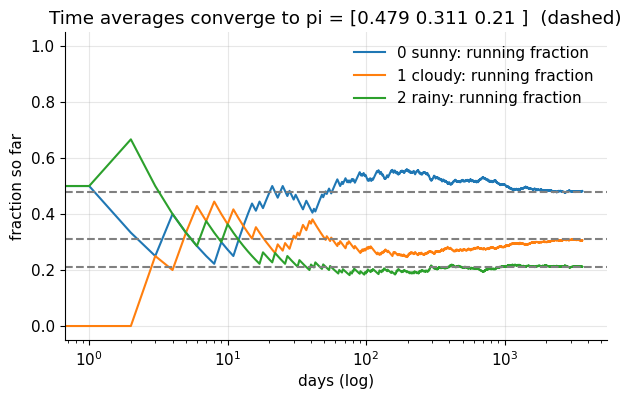

10-year occupancy: [0.4823 0.3057 0.212 ]   mean return times: [2.09 3.22 4.76]


In [11]:
# --- Simulate 10 years of weather: running fractions vs pi ---------------------------
x = weather.sample_path(3650, x0=2, rng=rng)
run = np.cumsum(np.eye(3)[x], axis=0) / np.arange(1, len(x) + 1)[:, None]
pi_ref = weather.stationary()
plt.figure()
for j, s in enumerate(["0 sunny", "1 cloudy", "2 rainy"]):
    plt.plot(run[:, j], label=f"{s}: running fraction"); plt.axhline(pi_ref[j], ls="--", c="gray")
plt.xscale("log"); plt.xlabel("days (log)"); plt.ylabel("fraction so far"); plt.legend()
plt.title(f"Time averages converge to pi = {np.round(pi_ref, 3)}  (dashed)"); plt.show()
print("10-year occupancy:", weather.occupancy(x).round(4), "  mean return times:", weather.mean_return_times().round(2))

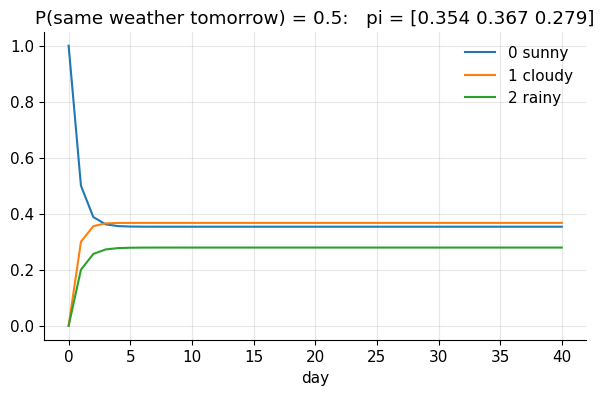

In [12]:
def weather_exp(stickiness=0.5):
    """Scale the diagonal of P: sticky weather converges slower, pi barely moves."""
    P = P_w.copy(); np.fill_diagonal(P, 0)
    P = P / P.sum(axis=1, keepdims=True) * (1 - stickiness) + stickiness * np.eye(3)
    ch = DTMC(P, W); path = ch.distribution_path([1, 0, 0], 40)
    plt.figure()
    for j, s in enumerate(["0 sunny", "1 cloudy", "2 rainy"]): plt.plot(path[:, j], label=s)
    plt.title(f"P(same weather tomorrow) = {stickiness}:   pi = {np.round(ch.stationary(), 3)}"); plt.xlabel("day"); plt.legend(); plt.show()

show(weather_exp, stickiness=FloatSlider(min=0, max=.95, step=.05, value=.5) if HAS_W else .5)

**Think about it** — (i) Why is exactly one balance equation redundant?
(Add the three equations $\pi_j=\sum_i\pi_iP_{ij}$.) (ii) In the experiment the
diagonal changes a lot but $\pi$ barely moves. What does $\pi$ depend on — the
*speed* of the chain, or the *ratios* of flows between states?

---
## Problem 3 — Umbrellas: limits, wet trips, and the optimal $r$ *(slide p. 42/52)*

> Consider problem #5 in Class Problems 3 on DTMC modeling about this lady with
> $r$ umbrellas. Compute the limiting probabilities $(\pi_0,\pi_1,\dots,\pi_r)$
> and also determine the fraction of trips the individual becomes wet ($\varphi$).
> Every time the individual becomes wet, it costs $c$ won to recover [...]. Also
> the maintenance cost for $r$ umbrellas is $d$ won per umbrella per trip [...].
> Let $\tau$ be the long-run average cost per trip, then $\tau=c\varphi+dr$.
> **In terms of $p$, $c$ and $d$, determine the optimal number of umbrellas the
> individual should possess.**

### Model
Balance equations (Companion Proof 5): $\pi_r=\pi_0+p\,\pi_1$,
$\pi_{r-i}=(1-p)\pi_i+p\,\pi_{i+1}$ ($1\le i<r$), $\pi_0=(1-p)\pi_r$. The solution is
$$\pi_0=\frac{1-p}{r+1-p},\qquad \pi_i=\frac{1}{r+1-p}\ (i=1,\dots,r),\qquad
\varphi=p\,\pi_0=\frac{p(1-p)}{r+1-p}.$$
Then $\tau(r)=c\,\dfrac{p(1-p)}{r+1-p}+d\,r$ — a convex trade-off; the continuous
optimum is $r^\ast=\sqrt{c\,p(1-p)/d}-(1-p)$, rounded to a neighbouring integer.

In [13]:
def umbrella_P(r, p):
    P = np.zeros((r + 1, r + 1)); P[0, r] = 1
    for i in range(1, r + 1):
        P[i, r - i] += 1 - p; P[i, r - i + 1] += p
    return P

r, p = 3, 0.4
umb = DTMC(umbrella_P(r, p), list(range(r + 1)))
pi_formula = np.r_[1 - p, np.ones(r)] / (r + 1 - p)
phi = p * (1 - p) / (r + 1 - p)
print("pi (formula):", pi_formula.round(4)); print("pi (solver) :", umb.stationary().round(4))
print(f"wet fraction phi = {phi:.4f}")

c, d = 50_000, 500                      # won per wetting, won per umbrella per trip
def tau(r, p=p, c=c, d=d): return c * p * (1 - p) / (r + 1 - p) + d * r
rs = np.arange(0, 21); costs = tau(rs)
r_opt = int(rs[np.argmin(costs)])
print(f"optimal r = {r_opt}   (continuous r* = {np.sqrt(c*p*(1-p)/d) - (1-p):.2f})")

pi (formula): [0.1667 0.2778 0.2778 0.2778]
pi (solver) : [0.1667 0.2778 0.2778 0.2778]
wet fraction phi = 0.0667
optimal r = 4   (continuous r* = 4.30)


In [14]:
check("pi_0 (r=3, p=.4)", None if pi_formula is Ellipsis else pi_formula[0], 0.6/3.6, tol=1e-9)
check("phi",              phi, 0.4*0.6/3.6, tol=1e-9)
check("tau(3)",           tau(3), 50_000*0.4*0.6/3.6 + 500*3, tol=1e-6)
check("optimal r",        r_opt, int(np.arange(0, 21)[np.argmin(50_000*0.4*0.6/(np.arange(0, 21)+0.6) + 500*np.arange(0, 21))]), tol=0.5)

[OK ] pi_0 (r=3, p=.4): got 0.166667   (reference 0.166667)
[OK ] phi: got 0.0666667   (reference 0.0666667)
[OK ] tau(3): got 4833.33   (reference 4833.33)
[OK ] optimal r: got 4   (reference 4)


True

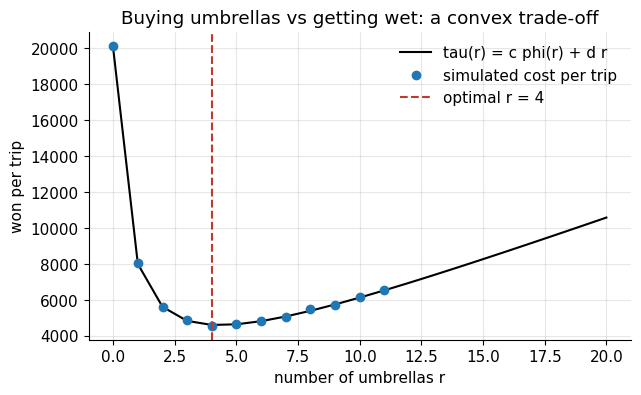

In [15]:
# --- Simulate the cost per trip for each r and overlay tau(r) --------------------
if r_opt is None:
    print("(finish the TODOs first)")
else:
    sim_cost = []
    for k in rs[:12]:
        ch = DTMC(umbrella_P(int(k), p), list(range(int(k) + 1)))
        x = ch.sample_path(100_000, rng=rng)
        wet = (x[:-1] == 0) & (rng.random(len(x) - 1) < p)
        sim_cost.append(c * wet.mean() + d * k)
    plt.figure()
    plt.plot(rs, costs, "k-", label="tau(r) = c phi(r) + d r")
    plt.plot(rs[:12], sim_cost, "o", label="simulated cost per trip")
    plt.axvline(r_opt, ls="--", c="#c0392b", label=f"optimal r = {r_opt}")
    plt.xlabel("number of umbrellas r"); plt.ylabel("won per trip"); plt.legend()
    plt.title("Buying umbrellas vs getting wet: a convex trade-off"); plt.show()

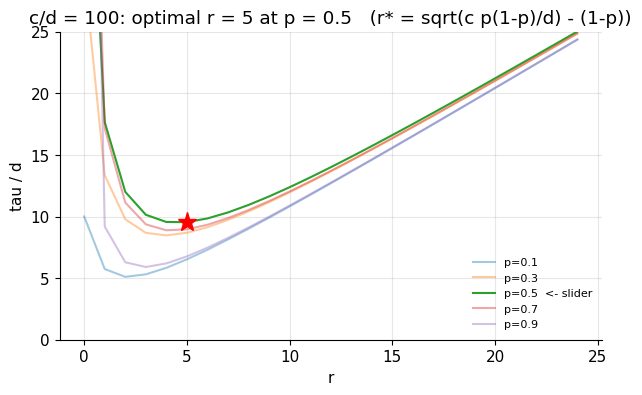

In [16]:
def umbrella_opt(p=0.4, c_over_d=100.0):
    rs = np.arange(0, 25)
    plt.figure()
    for pp in [0.1, 0.3, 0.5, 0.7, 0.9]:
        t = c_over_d * pp * (1 - pp) / (rs + 1 - pp) + rs
        plt.plot(rs, t, "-", alpha=.4 if pp != p else 1, label=f"p={pp}" + ("  <- slider" if pp == p else ""))
    t = c_over_d * p * (1 - p) / (rs + 1 - p) + rs
    plt.plot(rs[np.argmin(t)], t.min(), "r*", ms=14)
    plt.xlabel("r"); plt.ylabel("tau / d"); plt.ylim(0, 25); plt.legend(fontsize=8)
    plt.title(f"c/d = {c_over_d:.0f}: optimal r = {rs[np.argmin(t)]} at p = {p}   (r* = sqrt(c p(1-p)/d) - (1-p))"); plt.show()

show(umbrella_opt,
     p=FloatSlider(min=.1, max=.9, step=.2, value=.5) if HAS_W else .5,
     c_over_d=FloatLogSlider(min=0, max=3, step=.25, value=100) if HAS_W else 100.0)

**Think about it** — (i) Rain probability $p=0.5$ is the *worst* case for
her (not $p=0.9$!). Explain via $\varphi\propto p(1-p)$: what two things must
happen for a wet trip? (ii) $\tau$ mixes a *stationary* probability with a
*per-trip* cost. Which theorem lets us multiply them and call the result a
long-run average? *(Companion Proof 6.)*

---
## Problem 4 — Machine tool: steady state, average age, average lifetime *(slide p. 46/52)*

> Consider problem #6 in Class Problems 3 on DTMC modeling where if a machine
> tool produced $i$ parts, it fails with probability $p_i$. Let $X_n$ be the age
> of a machine tool at the beginning of the $n$-th hour. **Compute the steady
> state distribution for the DTMC. What is the average age of a tool when it
> starts processing a part? What is the average lifetime of a tool?**

### Model
Balance for $i\ge1$: the only way into $i$ is from $i-1$, so
$\pi_i=(1-p_{i-1})\,\pi_{i-1}\Rightarrow\pi_i=\pi_0\prod_{k<i}(1-p_k)$;
normalising, $\pi_0=1/\sum_i\prod_{k<i}(1-p_k)$.
- average age at the start of an hour $=\sum_i i\,\pi_i$ (a cost with $C(i)=i$);
- average lifetime $=$ mean return time to age 0 $=1/\pi_0=\sum_{i\ge0}P(L>i)$ —
  the tail-sum formula of Ch.1–3 appears again.

In [17]:
p_fail = np.array([0.05, 0.10, 0.20, 0.40, 0.70, 1.00])
K = len(p_fail) - 1
P_t = np.zeros((K + 1, K + 1))
for i in range(K + 1):
    P_t[i, 0] = p_fail[i]
    if i < K: P_t[i, i + 1] = 1 - p_fail[i]
tool = DTMC(P_t, list(range(K + 1)))

surv = np.cumprod(np.r_[1.0, 1 - p_fail[:-1]])     # prod_{k<i}(1-p_k),  i = 0..K
pi_tool = surv / surv.sum()
avg_age  = float(pi_tool @ np.arange(K + 1))
lifetime = 1 / pi_tool[0]
print("pi (product formula):", pi_tool.round(4)); print("pi (solver)         :", tool.stationary().round(4))
print(f"average age at start of an hour = {avg_age:.3f} parts")
print(f"average lifetime = 1/pi_0 = {lifetime:.3f} h  = tail sum {surv.sum():.3f}")

pi (product formula): [0.2486 0.2362 0.2126 0.17   0.102  0.0306]
pi (solver)         : [0.2486 0.2362 0.2126 0.17   0.102  0.0306]
average age at start of an hour = 1.733 parts
average lifetime = 1/pi_0 = 4.023 h  = tail sum 4.023


In [18]:
_s = np.cumprod(np.r_[1.0, 1 - np.array([0.05, 0.10, 0.20, 0.40, 0.70])])
check("pi_0",       None if pi_tool is Ellipsis else pi_tool[0], 1/_s.sum(), tol=1e-9)
check("avg age",    avg_age,  float((_s/_s.sum()) @ np.arange(6)), tol=1e-9)
check("lifetime",   lifetime, _s.sum(), tol=1e-9)

[OK ] pi_0: got 0.2486   (reference 0.2486)
[OK ] avg age: got 1.73255   (reference 1.73255)
[OK ] lifetime: got 4.02252   (reference 4.02252)


np.True_

sim average age 1.731   sim average lifetime 4.021   sim pi_0 0.2487


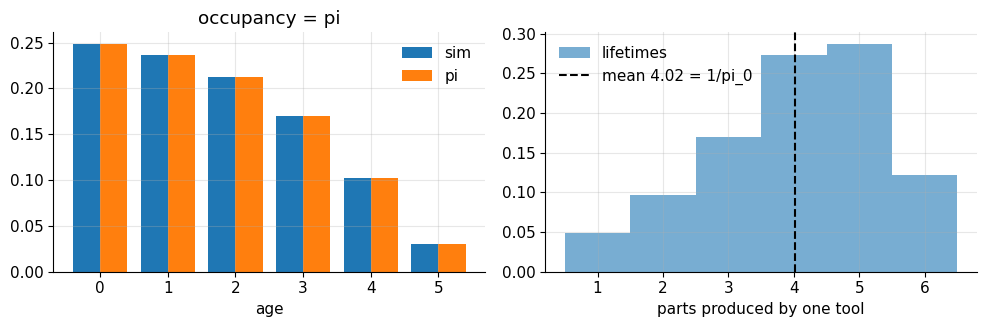

In [19]:
# --- Simulate: ages seen hour by hour, and lifetimes between replacements ----------
x = tool.sample_path(300_000, x0=0, rng=rng)
life = np.diff(np.where(x == 0)[0])
print(f"sim average age {x.mean():.3f}   sim average lifetime {life.mean():.3f}   sim pi_0 {np.mean(x == 0):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].bar(np.arange(K + 1) - .2, tool.occupancy(x), .4, label="sim"); ax[0].bar(np.arange(K + 1) + .2, tool.stationary(), .4, label="pi")
ax[0].set_xlabel("age"); ax[0].set_title("occupancy = pi"); ax[0].legend()
ax[1].hist(life, bins=np.arange(.5, K + 2), density=True, alpha=.6, label="lifetimes")
ax[1].axvline(life.mean(), c="k", ls="--", label=f"mean {life.mean():.2f} = 1/pi_0"); ax[1].set_xlabel("parts produced by one tool"); ax[1].legend()
plt.tight_layout(); plt.show()

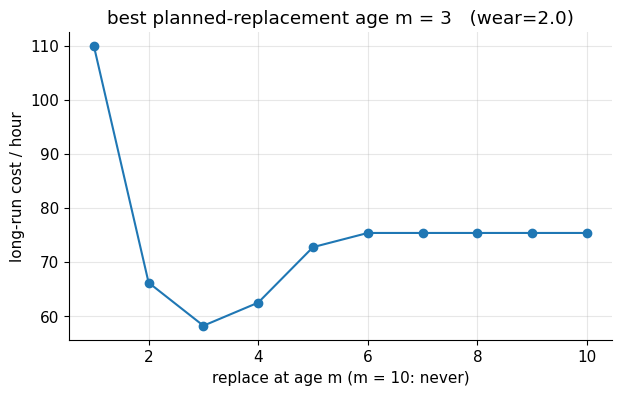

In [20]:
def tool_cost_exp(replace_cost=100.0, wear=2.0):
    """Planned replacement when the age reaches m (cost replace_cost) vs a failure in service
    (cost replace_cost + 200 for the scrapped part). Which m minimises the long-run cost per hour?"""
    pf = np.minimum(1.0, 0.05 * wear ** np.arange(0, 10)); pf[-1] = 1.0
    ms = np.arange(1, len(pf) + 1); costs = []
    for m in ms:                                   # states 0..m-1; from m-1 the tool is always replaced
        P = np.zeros((m, m))
        for i in range(m):
            P[i, 0] = pf[i] if i < m - 1 else 1.0
            if i < m - 1: P[i, i + 1] = 1 - pf[i]
        pi = DTMC(P).stationary()
        fail    = float(pi @ pf[:m])                       # failures per hour
        planned = float(pi[m - 1] * (1 - pf[m - 1]))       # survived to age m -> planned swap
        costs.append(replace_cost * (fail + planned) + 200 * fail)
    plt.figure(); plt.plot(ms, costs, "o-"); plt.xlabel("replace at age m (m = 10: never)"); plt.ylabel("long-run cost / hour")
    plt.title(f"best planned-replacement age m = {ms[np.argmin(costs)]}   (wear={wear})"); plt.show()

show(tool_cost_exp,
     replace_cost=FloatSlider(min=10, max=500, step=10, value=100) if HAS_W else 100.0,
     wear=FloatSlider(min=1.2, max=3, step=.1, value=2.0) if HAS_W else 2.0)

**Think about it** — (i) "Average age" $\sum_i i\pi_i$ and "average lifetime"
$1/\pi_0$ are different numbers. Which one would an inspector see who walks in
at a random hour, and why is that the *inspection paradox* in disguise (Ch.7)?
(ii) When does planned replacement beat run-to-failure in the experiment — for
increasing $p_i$ (wear-out) or for constant $p_i$? Argue from memorylessness.

---
## Problem 5 — Kim's lunch *(slides pp. 49–50/52)*

> Kim is a student that goes out to eat lunch everyday. He eats either at a
> Korean food place (0), Chinese food place (1), or Burger place (2). The place
> Kim chooses to go for lunch on day $n$ can be modeled as a DTMC with transition
> matrix
> $$\begin{pmatrix}0.3&0.3&0.4\\1&0&0\\0.5&0.5&0\end{pmatrix}.$$
> [...] **Are there any absorption states? Is the DTMC ergodic?**
> (a) After several days (assume steady state is reached) if you ask Kim what he
> had for lunch, what is the probability that he would say "burger"?
> (b) If on day $n=1000$ Kim went to the Korean food place, what is the
> probability that on day $n=1001$ he will go to the Chinese food place?
> (c) If all the students at Kim's university follow the above Markov chain, in
> the long run, what fraction of the students going to lunch eat at the Chinese
> food place?
> (d) Continuing with question (c) above, if the average cost per lunch is
> 4,000 won in the Burger place, 6,000 won in the Chinese place and 5,000 won in
> the Korean place, what is the average revenue per day per customer from all
> the three eating places together?
> (e) How much does Kim spend on lunch (on average) everyday?

### Model
No absorbing state ($P_{ii}<1$ for all $i$). $0\to1\to0$ and $0\to2\to0$ make the
chain irreducible; the self-loop $P_{00}>0$ makes it aperiodic ⇒ **ergodic**.
(a) $\pi_2$. (b) $P_{01}=0.3$ — time-homogeneity, day 1000 is irrelevant.
(c) $\pi_1$: for a large population the fraction equals the probability.
(d) revenue $=\sum_i C(i)\pi_i$. (e) Kim's *time* average is the same number —
ergodicity says time average $=$ ensemble average.

In [21]:
kim = DTMC([[0.3, 0.3, 0.4], [1, 0, 0], [0.5, 0.5, 0]], ["Korean", "Chinese", "Burger"])
print(kim.summary())
pi_k = kim.stationary()
cost = np.array([5000, 6000, 4000])

ans_a = pi_k[2]
ans_b = kim.P[0, 1]
ans_c = pi_k[1]
ans_d = kim.long_run_cost(cost)
ans_e = ans_d
print(f"pi = {pi_k.round(4)}  (exact: 10/19, 5/19, 4/19)")
print(f"(a) {ans_a:.4f}  (b) {ans_b:.2f}  (c) {ans_c:.4f}  (d) {ans_d:.1f} won  (e) {ans_e:.1f} won")

3 states; 1 communicating class(es)
  ['Korean', 'Chinese', 'Burger']: recurrent, period 1
absorbing: none
ergodic: True
pi = [0.5263 0.2632 0.2105]  (exact: 10/19, 5/19, 4/19)
(a) 0.2105  (b) 0.30  (c) 0.2632  (d) 5052.6 won  (e) 5052.6 won


In [22]:
check("(a) pi_burger",  ans_a, 4/19, tol=1e-9)
check("(b) P[K->C]",     ans_b, 0.3,  tol=1e-9)
check("(c) pi_chinese",  ans_c, 5/19, tol=1e-9)
check("(d) revenue/day", ans_d, (50000 + 30000 + 16000)/19, tol=1e-6)
check("(e) Kim's spend", ans_e, (50000 + 30000 + 16000)/19, tol=1e-6)

[OK ] (a) pi_burger: got 0.210526   (reference 0.210526)
[OK ] (b) P[K->C]: got 0.3   (reference 0.3)
[OK ] (c) pi_chinese: got 0.263158   (reference 0.263158)
[OK ] (d) revenue/day: got 5052.63   (reference 5052.63)
[OK ] (e) Kim's spend: got 5052.63   (reference 5052.63)


True

time average (Kim, 3000 days):    [0.524 0.263 0.212]   spend 5051 won/day
ensemble (3000 students, day 30): [0.51133333 0.27       0.21866667]   revenue 5051 won/day
pi:                               [0.526 0.263 0.211]   5053 won/day


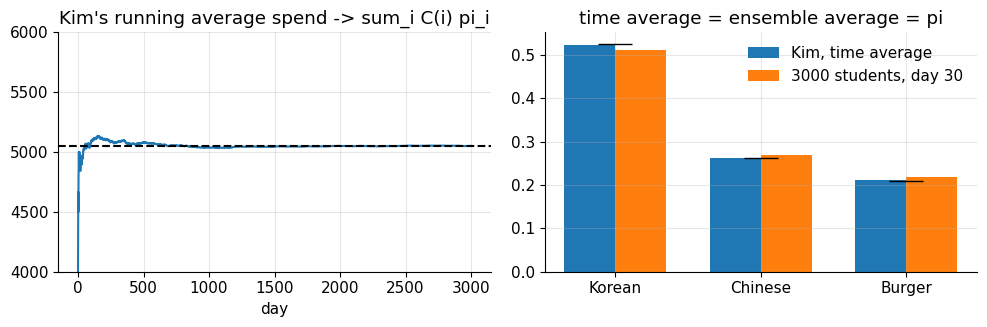

In [23]:
# --- Ergodicity, seen: ONE student over 3000 days  vs  3000 students on day 30 -----
one = kim.sample_path(3000, x0="Burger", rng=rng)                       # time average
many = np.array([kim.sample_path(30, x0="Burger", rng=rng)[-1] for _ in range(3000)])  # ensemble at day 30
print("time average (Kim, 3000 days):   ", kim.occupancy(one).round(3), f"  spend {cost[one].mean():.0f} won/day")
print("ensemble (3000 students, day 30):", np.bincount(many, minlength=3).round(3) / 3000, f"  revenue {cost[many].mean():.0f} won/day")
print("pi:                              ", pi_k.round(3), f"  {ans_d if ans_d is not Ellipsis else float('nan'):.0f} won/day")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(np.cumsum(cost[one]) / np.arange(1, len(one) + 1)); ax[0].axhline(pi_k @ cost, ls="--", c="k")
ax[0].set_title("Kim's running average spend -> sum_i C(i) pi_i"); ax[0].set_xlabel("day"); ax[0].set_ylim(4000, 6000)
w = .35; xs = np.arange(3)
ax[1].bar(xs - w/2, kim.occupancy(one), w, label="Kim, time average"); ax[1].bar(xs + w/2, np.bincount(many, minlength=3)/3000, w, label="3000 students, day 30")
ax[1].plot(xs, pi_k, "k_", ms=25); ax[1].set_xticks(xs, kim.states); ax[1].legend(); ax[1].set_title("time average = ensemble average = pi")
plt.tight_layout(); plt.show()

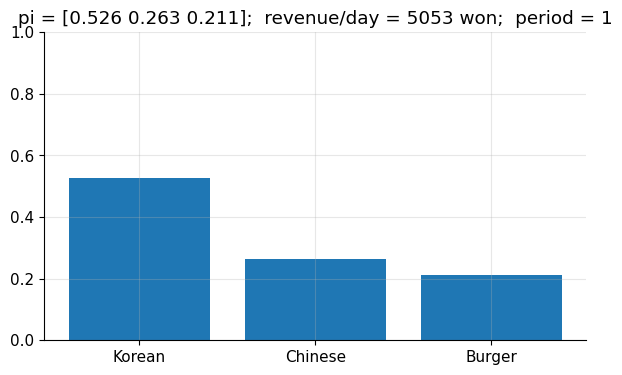

In [24]:
def kim_exp(p_stay_korean=0.3, p_burger=0.4):
    if p_stay_korean + p_burger > 1: print("row 0 exceeds 1"); return
    P = np.array([[p_stay_korean, 1 - p_stay_korean - p_burger, p_burger], [1, 0, 0], [0.5, 0.5, 0]])
    ch = DTMC(P, kim.states); pi = ch.stationary()
    plt.figure(); plt.bar(kim.states, pi)
    plt.title(f"pi = {np.round(pi, 3)};  revenue/day = {ch.long_run_cost(cost):.0f} won;  period = {ch.period()}"); plt.ylim(0, 1); plt.show()

show(kim_exp,
     p_stay_korean=FloatSlider(min=0, max=1, step=.05, value=.3) if HAS_W else .3,
     p_burger=FloatSlider(min=0, max=1, step=.05, value=.4) if HAS_W else .4)

**Think about it** — (i) Set `p_stay_korean = 0` and `p_burger = 0` in the
experiment. The chain becomes periodic: $\pi$ still exists — what does it mean
now, and why does "ask Kim after several days" (question (a)) break? (ii)
Questions (d) and (e) have the same answer for different reasons — state both
reasons in one sentence each.

---
## Wrap-up

| # | system | $\pi$ | quantity | value |
|---|---|---|---|---|
| 1 | machine | $(0.0202, 0.9798)$ | availability | $0.9798$ |
| 2 | weather | solve 3×3 | fractions | $(0.479, 0.311, 0.210)$ |
| 3 | umbrellas | $\pi_0=\frac{1-p}{r+1-p}$ | wet fraction, $\tau(r)$ | $\varphi=\frac{p(1-p)}{r+1-p}$ |
| 4 | tool age | $\pi_i\propto\prod_{k<i}(1-p_k)$ | mean age, lifetime $=1/\pi_0$ | tail sum |
| 5 | Kim | $(10,5,4)/19$ | revenue $\sum C(i)\pi_i$ | $5052.6$ won |

**Next steps** → Companion Ch.4 Proofs 3–6 (classification, two-state $P^n$,
$\pi$ as long-run fraction, cost formula) → PageRank practicum → HW 2
(Part A *without* AI first).